# Water Potability

In this analysis, I explored the dataset Water Potability from Kaggle Water-Potability which contains 3276 entries and 9 features that determine the water potability. An extensive explanation of these features is provided on the dataset´s Kaggle page.

**Objective**

Predict the potability of the water based on the values of its features: pH, hardness, solids, chloramines, sulfate, conductivity, organic carbon, trihalomethanes, and turbidity.

In [1]:
# To import the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# read dataset
df = pd.read_csv("water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


### 📊 Exploratory Data Analysis
Visualizing the distribution of each feature to understand the data better.

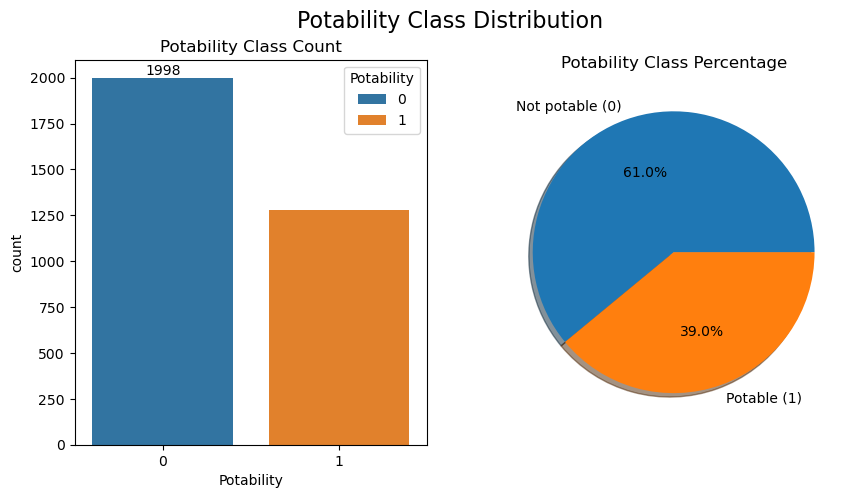

In [5]:
# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Bar plot of Potability counts
sns.countplot(data=df, x="Potability", hue="Potability", ax=ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].set_title("Potability Class Count")

# Pie chart of Potability distribution
labels = {0: 'Not potable (0)', 1: 'Potable (1)'}
df['Potability'].value_counts().rename(index=labels).plot.pie(
    ax=ax[1], autopct='%1.1f%%', shadow=True, textprops={'fontsize': 10}, ylabel=''
)
ax[1].set_title("Potability Class Percentage")

plt.suptitle("Potability Class Distribution", fontsize=16)
plt.show()

### The result shows, that target variable Potability is imbalanced about 61% not potable (0) and 39% potable (1)

### Missing Values

In [6]:
# The number of missing values
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [7]:
# Percentage of missing values
df.isnull().sum() / len(df) * 100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [8]:
# Total Percentage  of missing values
total_missing = df.isnull().sum().sum() / len(df) * 100
print(f"Total Porcentage  of missing values:  {total_missing:.2f}%")

Total Porcentage  of missing values:  43.77%


In [9]:
df.isnull().groupby(df['Potability']).sum()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
Potability,,,,,,,,,,
0,314,0,0,0,488,0,0,107,0,0
1,177,0,0,0,293,0,0,55,0,0


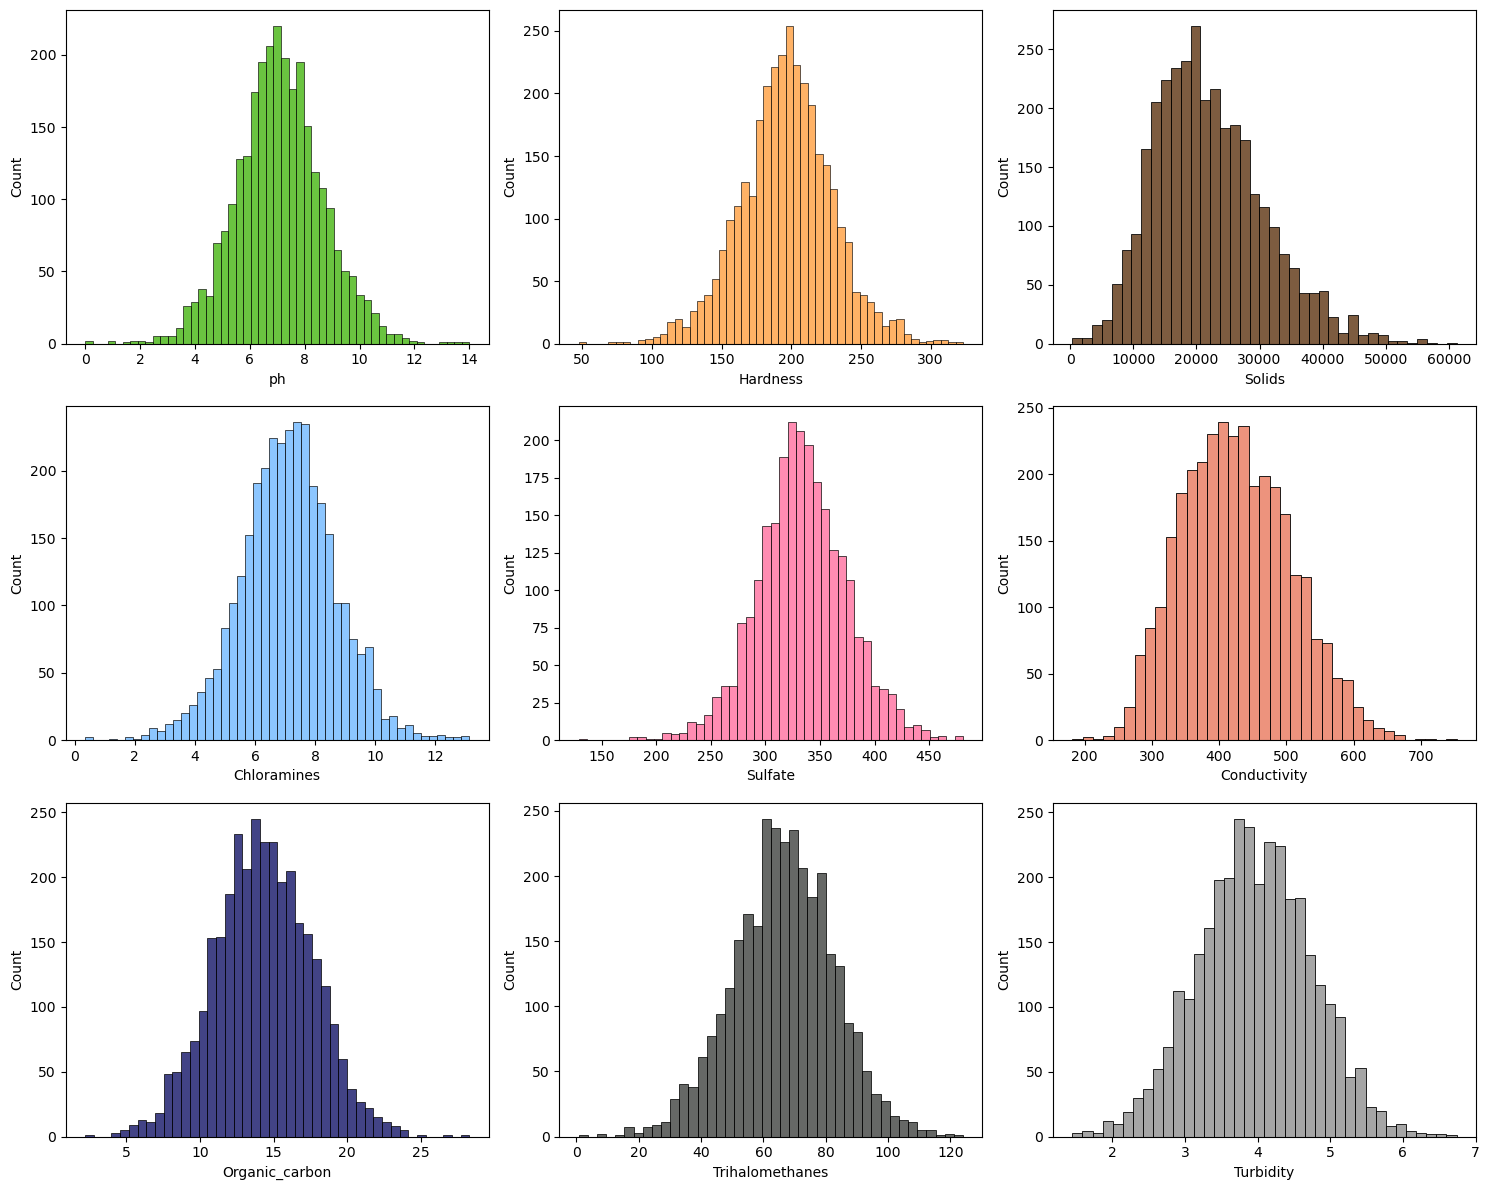

In [10]:
fig, axs = plt.subplots(3, 3, figsize=(15,12))
axs = axs.flatten()
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
colors = ['#38b000', '#FF9933', '#522500', '#66b3ff', '#FF6699', '#e76f51', '#03045e', '#333533', '#888988']

for i, feature in enumerate(features):
    sns.histplot(df[feature], color=colors[i], ax=axs[i])
plt.tight_layout()

### 🧹 Handling Outliers

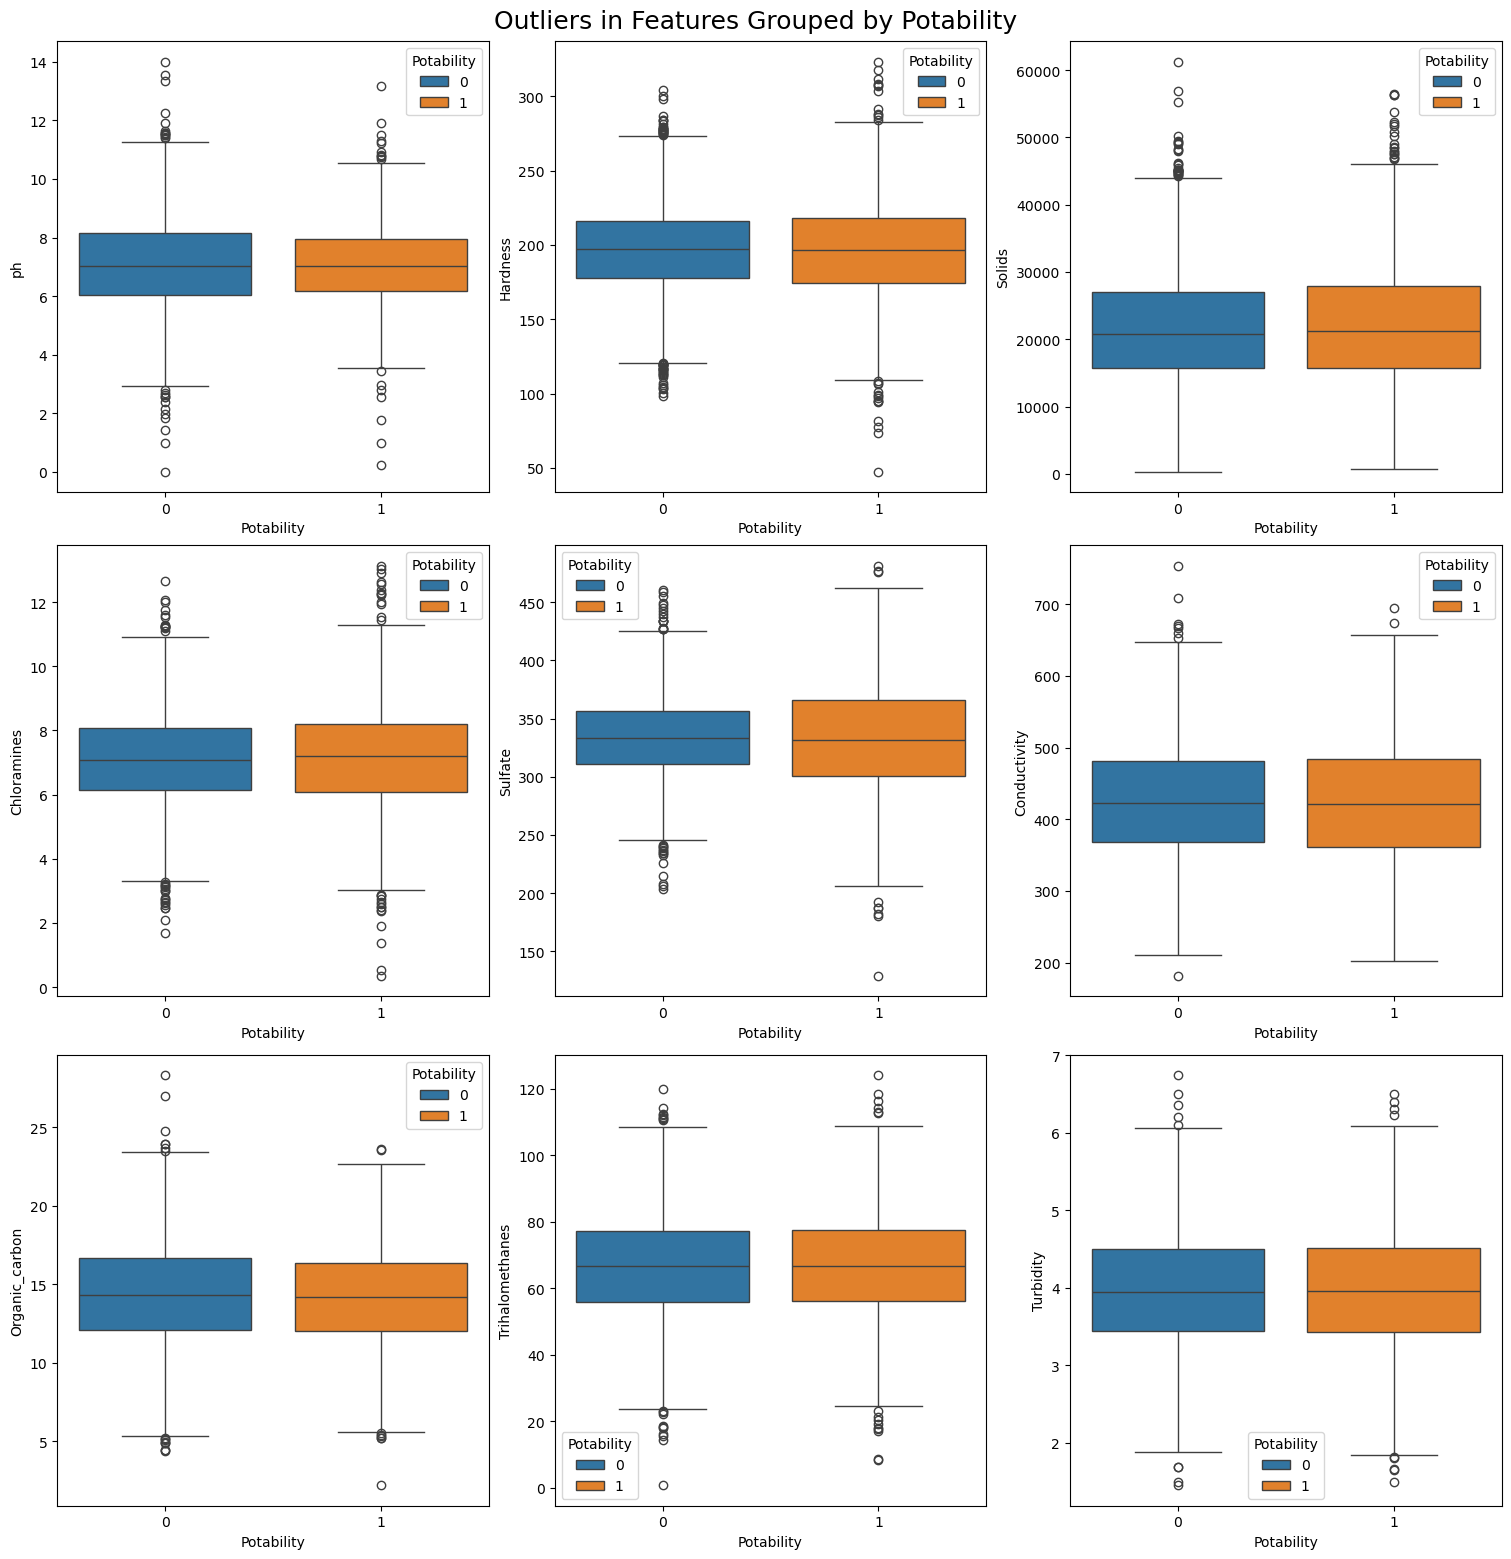

In [11]:
# Features to plot
features = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate", 
            "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]

# Create subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 20), constrained_layout=True)
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    sns.boxplot(x="Potability", y=feature, data=df, ax=axes[i], hue="Potability")

# Remove unused axes
for ax in axes[len(features):]:
    fig.delaxes(ax)

# Title and display
fig.suptitle("Outliers in Features Grouped by Potability", fontsize=18)
plt.show()

In [12]:
# Count outliers
def outliers(df):
  Q1 = df.quantile(0.25)
  Q3 = df.quantile(0.75)
  IQR = Q3 - Q1
  outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
  return outliers

In [13]:
outliers_df = outliers(df)
pd.DataFrame({"Count.Outliers": outliers_df.sum(),
            "Pct.Outliers %": (outliers_df.sum() * 100/ len(df)).round(2)})

,Count.Outliers,Pct.Outliers %
ph,46,1.40
Hardness,83,2.53
Solids,47,1.43
Chloramines,61,1.86
Sulfate,41,1.25
Conductivity,11,0.34
Organic_carbon,25,0.76
Trihalomethanes,33,1.01
Turbidity,19,0.58
Potability,0,0.00


**Hardness has the most outliers.**

In [14]:
# Total percentage of outliers
total_outliers = outliers_df.sum().sum() / len(df) * 100
print(f'Total percentage of outliers: {total_outliers:.2f}%')

Total percentage of outliers: 11.17%


### Note:
**This dataset has 43.8 % of missing values and 11.17 % of outliers.**
# Preprocessing
**Use mean imputation because the data is normally distributed.**

In [15]:
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())

In [16]:
# The number of missing values
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

**You’ve already identified outliers using IQR. Now let’s cap them using Winsorization (clipping extreme values):**

In [17]:
# Cap outliers at 1st and 99th percentiles
for col in df.select_dtypes(include='float64').columns:
    lower = df[col].quantile(0.25)
    upper = df[col].quantile(0.75)
    df[col] = df[col].clip(lower, upper)

### Creating Interactive Feature Classification

* Direct Chemical Interactions:
pH affects solubility and reactions

* Ion Content and Conductivity:
Solids, Sulfate, Hardness affect Conductivity.

In [18]:
# Interaction Feature: Hardness * Organic Carbon
df['Hardness_Organic_Carbon'] = df['Hardness'] * df['Organic_carbon']

# Interaction Feature: Hardness * Organic Carbon
df['ph_Hardness'] = df['ph'] * df['Hardness']

# Interaction Feature: Hardness * Organic Carbon
df['ph_Conductivity'] = df['ph'] * df['Conductivity']

In [19]:
# The number of missing values
df.isnull().sum()

ph                         0
Hardness                   0
Solids                     0
Chloramines                0
Sulfate                    0
Conductivity               0
Organic_carbon             0
Trihalomethanes            0
Turbidity                  0
Potability                 0
Hardness_Organic_Carbon    0
ph_Hardness                0
ph_Conductivity            0
dtype: int64

### Separate data into features and target

In [20]:
X = df.drop('Potability', axis=1)
y = df['Potability']

### Feature Scaling
**Standardize features to bring them to the same scale, especially important for models like SVC or Logistic Regression.**

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

### Train-Test data ratio allocation
* Train data = 80% while
* Test data = 20%

**Split your dataset into training and testing.**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Selection and Training

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Xgboost Classifier": XGBClassifier()
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n🔍 {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


🔍 Logistic Regression
Accuracy: 0.6097560975609756
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



🔍 Random Forest
Accuracy: 0.6432926829268293
              precision    recall  f1-score   support

           0       0.66      0.84      0.74       400
           1       0.58      0.33      0.42       256

    accuracy                           0.64       656
   macro avg       0.62      0.59      0.58       656
weighted avg       0.63      0.64      0.62       656


🔍 Gradient Boosting
Accuracy: 0.6509146341463414
              precision    recall  f1-score   support

           0       0.67      0.86      0.75       400
           1       0.60      0.33      0.42       256

    accuracy                           0.65       656
   macro avg       0.63      0.59      0.59       656
weighted avg       0.64      0.65      0.62       656


🔍 Support Vector Machine
Accuracy: 0.6448170731707317
              precision    recall  f1-score   support

           0       0.65      0.90      0.76       400
           1       0.61      0.25      0.35       256

    accuracy                   

# Hyperparameters Tuning

In [24]:
# Logistic Regression
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

# Random Forest
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Gradient Boosting
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

# Support Vector Machine
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# K-Nearest Neighbors
param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

# XGBClassifier
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [25]:
from sklearn.model_selection import GridSearchCV

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), param_lr),
    "Random Forest": (RandomForestClassifier(), param_rf),
    "Gradient Boosting": (GradientBoostingClassifier(), param_gb),
    "SVM": (SVC(), param_svm),
    "KNN": (KNeighborsClassifier(), param_knn),
    "Xgboost": (XGBClassifier(), param_xgb)
}

# Run tuning
best_models = {}
for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"\n🔧 {name} Best Parameters: {grid.best_params_}")
    print(f"✅ Accuracy: {grid.best_score_:.4f}")


🔧 Logistic Regression Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
✅ Accuracy: 0.6099

🔧 Random Forest Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
✅ Accuracy: 0.6580

🔧 Gradient Boosting Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
✅ Accuracy: 0.6477

🔧 SVM Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
✅ Accuracy: 0.6603

🔧 KNN Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}
✅ Accuracy: 0.6198

🔧 Xgboost Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
✅ Accuracy: 0.6534


# Resampling Techniques
Resampling techniques like RandomOverSampler, and SMOTE (oversampling) are powerful tools to handle class imbalance in classification problems.
### Apply RandomOverSampling
This creates synthetic samples for the minority class

In [26]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2620, 12)
y_train shape: (2620,)


In [27]:
from imblearn.over_sampling import RandomOverSampler

over_sampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = over_sampler.fit_resample(X_train,y_train)
print("X_train_over shape:", X_resampled.shape)
print("y_train_over shape:", y_resampled.shape)

X_train_over shape: (3196, 12)
y_train_over shape: (3196,)


In [28]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

### Model Selection and Training

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Xgboost Classifier": XGBClassifier()
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n🔍 {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


🔍 Logistic Regression
Accuracy: 0.55
              precision    recall  f1-score   support

           0       0.55      0.56      0.55       320
           1       0.55      0.54      0.55       320

    accuracy                           0.55       640
   macro avg       0.55      0.55      0.55       640
weighted avg       0.55      0.55      0.55       640


🔍 Random Forest
Accuracy: 0.7484375
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       320
           1       0.75      0.75      0.75       320

    accuracy                           0.75       640
   macro avg       0.75      0.75      0.75       640
weighted avg       0.75      0.75      0.75       640


🔍 Gradient Boosting
Accuracy: 0.696875
              precision    recall  f1-score   support

           0       0.70      0.69      0.70       320
           1       0.70      0.70      0.70       320

    accuracy                           0.70       640
   macro avg 

# Hyperparameters Tuning

In [30]:
# Logistic Regression
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

# Random Forest
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Gradient Boosting
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

# Support Vector Machine
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# K-Nearest Neighbors
param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

# XGBClassifier
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [31]:
from sklearn.model_selection import GridSearchCV

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), param_lr),
    "Random Forest": (RandomForestClassifier(), param_rf),
    "Gradient Boosting": (GradientBoostingClassifier(), param_gb),
    "SVM": (SVC(), param_svm),
    "KNN": (KNeighborsClassifier(), param_knn),
    "Xgboost": (XGBClassifier(), param_xgb)
}

# Run tuning
best_models = {}
for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"\n🔧 {name} Best Parameters: {grid.best_params_}")
    print(f"✅ Accuracy: {grid.best_score_:.4f}")


🔧 Logistic Regression Best Parameters: {'C': 10, 'solver': 'lbfgs'}
✅ Accuracy: 0.5215

🔧 Random Forest Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
✅ Accuracy: 0.7187

🔧 Gradient Boosting Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
✅ Accuracy: 0.7038

🔧 SVM Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Accuracy: 0.6405

🔧 KNN Best Parameters: {'n_neighbors': 7, 'weights': 'distance'}
✅ Accuracy: 0.6737

🔧 Xgboost Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
✅ Accuracy: 0.7148


# Great Job!!